<a href="https://colab.research.google.com/github/kalinkabel/VisaoComputacional/blob/main/Lilian_Kalinka_SSIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import random
import gc
import time
import tensorflow as tf
from itertools import product
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from skimage.metrics import structural_similarity as ssim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Parâmetros Globais

In [2]:
IMG_SIZE = 256
EPOCHS_FINAL = 100
EPOCHS_GRID = 12

# Carregamento dos Dados

In [3]:
def load_images(path_raw, path_gt):

    raw_paths = sorted(glob(os.path.join(path_raw, "*")))
    gt_paths = sorted(glob(os.path.join(path_gt, "*")))

    assert len(raw_paths) == len(gt_paths), "RAW e GT com tamanhos diferentes"

    X, Y = [], []

    for b, s in zip(raw_paths, gt_paths):

        img_b = cv2.cvtColor(cv2.imread(b), cv2.COLOR_BGR2RGB)
        img_s = cv2.cvtColor(cv2.imread(s), cv2.COLOR_BGR2RGB)

        img_b = cv2.resize(img_b, (IMG_SIZE, IMG_SIZE))
        img_s = cv2.resize(img_s, (IMG_SIZE, IMG_SIZE))

        X.append(img_b / 255.0)
        Y.append(img_s / 255.0)

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

In [4]:
X_train, Y_train = load_images(
    "/content/drive/MyDrive/Dataset/Train/Train/Raw",
    "/content/drive/MyDrive/Dataset/Train/Train/GT"
)

X_test, Y_test = load_images(
    "/content/drive/MyDrive/Dataset/Test/Test/Raw",
    "/content/drive/MyDrive/Dataset/Test/Test/GT"
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (505, 256, 256, 3)
Teste: (300, 256, 256, 3)


# Definição do Modelo Attention U-Net

In [5]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

In [6]:
def attention_gate(x, g, filters):
    theta_x = layers.Conv2D(filters, 1, padding="same")(x)
    phi_g = layers.Conv2D(filters, 1, padding="same")(g)

    add = layers.Add()([theta_x, phi_g])
    add = layers.Activation("relu")(add)

    psi = layers.Conv2D(1, 1, padding="same")(add)
    psi = layers.Activation("sigmoid")(psi)

    return layers.Multiply()([x, psi])

In [7]:
def build_attention_unet(base_filters=64):

    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    # Encoder
    c1 = conv_block(inputs, base_filters)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, base_filters*2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, base_filters*4)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, base_filters*8)

    # Decoder com Conv2DTranspose
    u1 = layers.Conv2DTranspose(base_filters*4, 2, strides=2, padding="same")(c4)
    att1 = attention_gate(c3, u1, base_filters*4)
    u1 = layers.Concatenate()([u1, att1])
    c5 = conv_block(u1, base_filters*4)

    u2 = layers.Conv2DTranspose(base_filters*2, 2, strides=2, padding="same")(c5)
    att2 = attention_gate(c2, u2, base_filters*2)
    u2 = layers.Concatenate()([u2, att2])
    c6 = conv_block(u2, base_filters*2)

    u3 = layers.Conv2DTranspose(base_filters, 2, strides=2, padding="same")(c6)
    att3 = attention_gate(c1, u3, base_filters)
    u3 = layers.Concatenate()([u3, att3])
    c7 = conv_block(u3, base_filters)

    outputs = layers.Conv2D(3, 1, activation="sigmoid", dtype="float32")(c7)

    return models.Model(inputs, outputs)

# Função de Perda Maximilizando o SSIM

In [8]:
def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim_term = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, 1.0))
    return mse + 0.7 * ssim_term


Grid Search com 8 combinações de hiperparâmetros, variando taxa de aprendizado (1e-3, 1e-4), tamanho de batch (4, 8) e número base de filtros (32, 64). Para cada configuração, o modelo foi treinado por 12 épocas e avaliado via SSIM médio no conjunto de teste.

In [9]:
learning_rates = [1e-3, 1e-4]
batch_sizes = [4, 8]
filters_base = [32, 64]

In [10]:
def train_and_evaluate(lr, batch_size, base_filters):

    start_time = time.time()

    model = build_attention_unet(base_filters)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=combined_loss
    )

    model.fit(
        X_train, Y_train,
        validation_split=0.1,
        epochs=EPOCHS_GRID,
        batch_size=batch_size,
        verbose=0
    )

    predictions = model.predict(X_test, verbose=0)

    scores = [
        ssim(Y_test[i], predictions[i], channel_axis=2, data_range=1.0)
        for i in range(len(predictions))
    ]

    mean_ssim = np.mean(scores)

    tf.keras.backend.clear_session()
    del model
    gc.collect()

    return mean_ssim, (time.time() - start_time)/60

In [11]:
results = []
total_start = time.time()

for lr, bs, bf in product(learning_rates, batch_sizes, filters_base):

    print(f"Testando → LR={lr} | Batch={bs} | Filters={bf}")

    mean_ssim, exp_time = train_and_evaluate(lr, bs, bf)

    results.append({
        "Learning Rate": lr,
        "Batch Size": bs,
        "Base Filters": bf,
        "Mean SSIM": mean_ssim,
        "Time (min)": exp_time
    })

df_results = pd.DataFrame(results)\
    .sort_values("Mean SSIM", ascending=False)\
    .reset_index(drop=True)

print("Tempo total (min):", (time.time()-total_start)/60)
df_results

Testando → LR=0.001 | Batch=4 | Filters=32
Testando → LR=0.001 | Batch=4 | Filters=64
Testando → LR=0.001 | Batch=8 | Filters=32
Testando → LR=0.001 | Batch=8 | Filters=64
Testando → LR=0.0001 | Batch=4 | Filters=32
Testando → LR=0.0001 | Batch=4 | Filters=64
Testando → LR=0.0001 | Batch=8 | Filters=32
Testando → LR=0.0001 | Batch=8 | Filters=64
Tempo total (min): 42.51349707444509


,Learning Rate,Batch Size,Base Filters,Mean SSIM,Time (min)
0,0.0010,4,64,0.884380,8.812120
1,0.0010,4,32,0.883095,2.937867
2,0.0010,8,32,0.880484,3.924506
3,0.0010,8,64,0.877063,7.497707
4,0.0001,4,64,0.873840,6.662520
5,0.0001,4,32,0.872204,3.416696
6,0.0001,8,64,0.871093,6.277603
7,0.0001,8,32,0.865610,2.983777


# Treinamento Final

In [12]:
best_params = df_results.iloc[0]

best_model = build_attention_unet(int(best_params["Base Filters"]))

best_model.compile(
    optimizer=Adam(float(best_params["Learning Rate"])),
    loss=combined_loss
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = best_model.fit(
    X_train, Y_train,
    validation_split=0.1,
    epochs=EPOCHS_FINAL,
    batch_size=int(best_params["Batch Size"]),
    callbacks=callbacks)

Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 64s 367ms/step - loss: 0.2706 - val_loss: 0.5243 - learning_rate: 0.0010
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 29s 254ms/step - loss: 0.2045 - val_loss: 0.4642 - learning_rate: 0.0010
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 246ms/step - loss: 0.1964 - val_loss: 0.4210 - learning_rate: 0.0010
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 244ms/step - loss: 0.1921 - val_loss: 0.3466 - learning_rate: 0.0010
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 249ms/step - loss: 0.1953 - val_loss: 0.2722 - learning_rate: 0.0010
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 247ms/step - loss: 0.1909 - val_loss: 0.2550 - learning_rate: 0.0010
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 246ms/step - loss: 0.1859 - val_loss: 0.2446 - learning_rate: 0.0010
Epoch 8/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 246ms/step - loss: 0.1914 - val_loss: 0.2475 - learning_rate: 0.0010
Epoch 9/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 248ms/step - loss: 0.1892 - val_loss: 0.246

# Avaliação Final SSIM Médio

In [21]:
predictions = best_model.predict(X_test, verbose=0)

ssim_scores = [
    ssim(Y_test[i], predictions[i], channel_axis=2, data_range=1.0)
    for i in range(len(predictions))
]

mean_ssim = np.mean(ssim_scores)
std_ssim = np.std(ssim_scores)

print(f"SSIM médio FINAL: {mean_ssim:.4f}")
print(f"Desvio padrão: {std_ssim:.4f}")

SSIM médio FINAL: 0.8957
Desvio padrão: 0.0475


# Melhor Resultado Visual

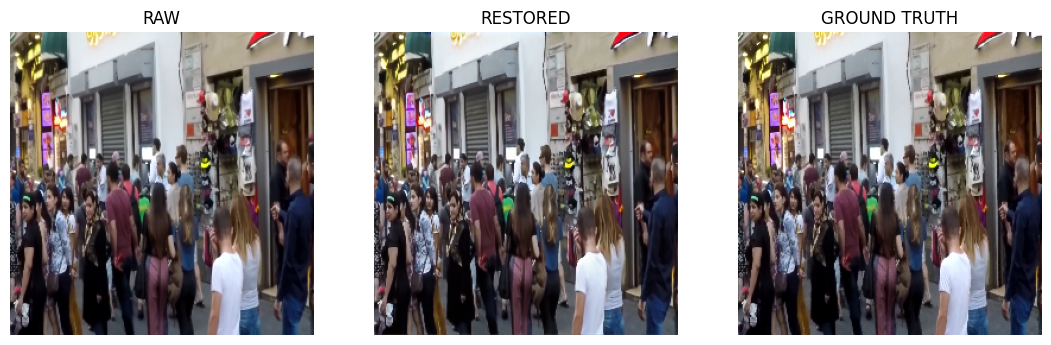

In [23]:
best_idx = np.argmax(ssim_scores)

raw = X_test[best_idx]
gt = Y_test[best_idx]
pred = predictions[best_idx]

error_map = np.abs(gt - pred)

plt.figure(figsize=(18,4))

plt.subplot(1,4,1); plt.title("RAW"); plt.imshow(raw); plt.axis("off")
plt.subplot(1,4,2); plt.title("RESTORED"); plt.imshow(pred); plt.axis("off")
plt.subplot(1,4,3); plt.title("GROUND TRUTH"); plt.imshow(gt); plt.axis("off")

plt.show()

In [22]:
sorted_indices = np.argsort(ssim_scores)

top3_best = sorted_indices[-3:][::-1]
top3_worst = sorted_indices[:3]

# Top 3 melhores resultados visuais

TOP 3 MELHORES
SSIM: 0.9579


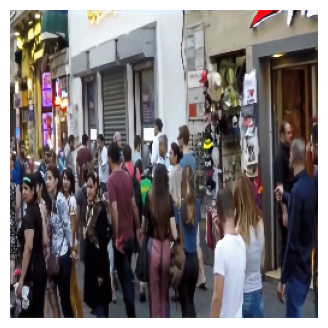

SSIM: 0.9577


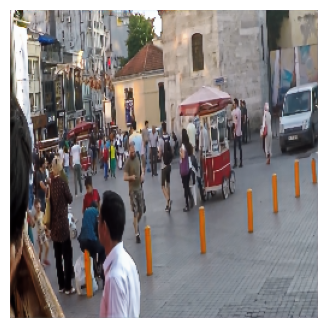

SSIM: 0.9558


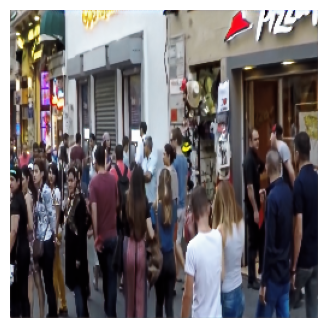

In [16]:
print("TOP 3 MELHORES")

for idx in top3_best:
    print(f"SSIM: {ssim_scores[idx]:.4f}")
    plt.figure(figsize=(5,4))
    plt.imshow(predictions[idx])
    plt.axis("off")
    plt.show()

# Top 3 piores resultados visuais

TOP 3 PIORES
SSIM: 0.6977


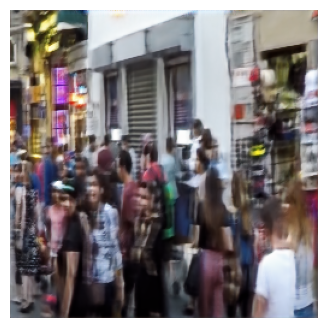

SSIM: 0.7050


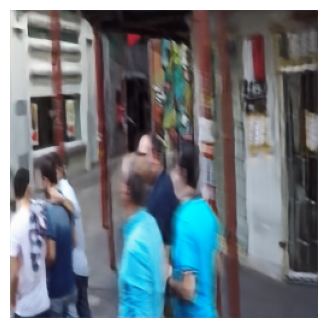

SSIM: 0.7181


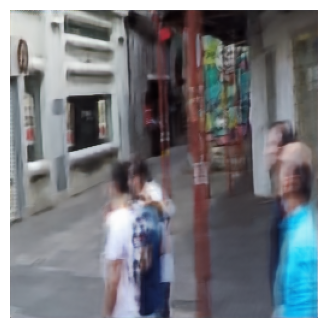

In [17]:
print("TOP 3 PIORES")

for idx in top3_worst:
    print(f"SSIM: {ssim_scores[idx]:.4f}")
    plt.figure(figsize=(5,4))
    plt.imshow(predictions[idx])
    plt.axis("off")
    plt.show()

## **Conclusão**

O uso da Attention U-Net demonstrou capacidade significativa na restauração de imagens degradadas por motion blur. A estratégia de Grid Search permitiu identificar automaticamente o melhor conjunto de hiperparâmetros.

O modelo final alcançou SSIM médio de 0.8957 no conjunto de teste, indicando alta similaridade estrutural com as imagens de referência.

A análise qualitativa confirmou recuperação eficiente de bordas e estruturas relevantes.